# Food Ordering Pattern Analysis using Apriori Algorithm

This notebook demonstrates Association Rule Mining on a food delivery dataset to find commonly ordered item combinations.

### Requirements:
- pandas
- mlxtend
- matplotlib
- seaborn

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import time
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
from mlxtend.preprocessing import TransactionEncoder

# Setting visualization style
plt.style.use('ggplot')
sns.set_palette("viridis")

## 1. Data Preparation

We load the dataset and convert the `Items_List` column into a transaction format (list of lists).

We apply One-Hot Encoding to convert the transactions (list of items per order) into a binary matrix format where:
  - Each column represents a unique item (e.g., burger, fries, coke)
  - Each row represents a transaction (order)
  - Value = 1 or True if the item exists in the order, otherwise 0 or False
  
This transformation is necessary because the Apriori algorithm requires data in a boolean (0/1) format to efficiently compute frequent itemsets and generate association rules.

In [35]:
# Load dataset
file_path = 'final_dataset2.csv'
df = pd.read_csv(file_path, engine='python', on_bad_lines='skip')

# Convert string representation of lists to actual Python lists.
# Like it "['burger', 'fries', 'coke']" To ['burger', 'fries', 'coke'] String not actual python list.
transactions = df['Items_List'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else []).tolist()

print(f"Total orders: {len(transactions)}")
print("Sample transaction:", transactions[0])

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
encoded_df = pd.DataFrame(te_ary, columns=te.columns_)

print("Encoded DataFrame Shape:", encoded_df.shape)
encoded_df.head()

Total orders: 20000
Sample transaction: ['Crispy Sandwich', 'Mozzarella Sticks', 'Juice']
Encoded DataFrame Shape: (20000, 46)


,7UP,Alfredo Pasta,BBQ Chicken Pizza,Beef Burger,Big Mac,Burrito,Cheesy Bread,Chicken Bucket,Chicken Fillet,Chicken Ranch,...,Shawarma,Soda,Spaghetti Bolognese,Sprite,Taco,Tamarind Juice,Thickburger,Twister,Wings,Zinger
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,True,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


## 2. Apriori Implementation

We generate frequent itemsets using different support thresholds (0.05, 0.1, 0.2).

In [36]:
thresholds = [0.05, 0.1, 0.2]
frequent_results = {}
summary = []

for support in thresholds:
    start = time.time()
    itemsets = apriori(encoded_df, min_support=support, use_colnames=True)
    end = time.time()
    
    frequent_results[support] = itemsets
    
    summary.append({
        "support": support,
        "num_itemsets": len(itemsets),
        "time": end - start
    })
    
    print(f"Support {support}: Found {len(itemsets)} frequent itemsets in {end-start:.4f}s")

# Convert summary to DataFrame
summary_df = pd.DataFrame(summary)

print("\nSupport Comparison:")
display(summary_df)

# Choose best support:
# We choose the support with the largest number of itemsets,
# but avoid cases where itemsets are too few.
best_support = summary_df.sort_values(
    by=["num_itemsets", "support"],
    ascending=[False, False]
).iloc[0]["support"]

print(f"\nBest selected support: {best_support}")

print(f"\nTop 10 Frequent Itemsets (Support >= {best_support}):")
frequent_results[best_support].sort_values(
    by="support",
    ascending=False
).head(10)

Support 0.05: Found 41 frequent itemsets in 0.0364s
Support 0.1: Found 9 frequent itemsets in 0.0102s
Support 0.2: Found 2 frequent itemsets in 0.0141s

Support Comparison:


,support,num_itemsets,time
0,0.05,41,0.036375
1,0.10,9,0.010220
2,0.20,2,0.014106



Best selected support: 0.05

Top 10 Frequent Itemsets (Support >= 0.05):


,support,itemsets
7,0.40805,(Fries)
15,0.22025,(Pepsi)
9,0.17345,(Juice)
14,0.15420,(Pepperoni Pizza)
33,0.12285,"(Pepsi, Fries)"
24,0.11245,(Thickburger)
5,0.10740,(Coke)
10,0.10710,(Koshary)
19,0.10660,(Shawarma)
2,0.09315,(Beef Burger)


## 3. Association Rules

Generate rules and filter based on Confidence (> 0.4) and Lift (> 1).

We use confidence > 0.4 to keep rules that have a reasonably strong relationship, meaning that if item A occurs, there is at least a 40% chance that item B also occurs.

We did not choose a higher value like 0.5 to avoid losing useful patterns and ending up with too few rules.

We also use lift > 1 to ensure that the relationship between items is meaningful and not due to random chance. A lift greater than 1 indicates a positive correlation, meaning the items appear together more often than expected.

In summary, these thresholds help us keep rules that are strong, useful, and statistically significant.

In [37]:
# Generate rules from the 0.05 threshold itemsets
rules = association_rules(frequent_results[0.05], metric="lift", min_threshold=1.0)

# Filtering Strong Rules
strong_rules = rules[(rules['confidence'] > 0.4) & (rules['lift'] > 1.0)]

print(f"Filtered to {len(strong_rules)} strong rules.")
print("\nTop 10 Rules sorted by Confidence:")

# Format for better display
display_df = strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
display_df['antecedents'] = display_df['antecedents'].apply(lambda x: list(x))
display_df['consequents'] = display_df['consequents'].apply(lambda x: list(x))
display_df.sort_values(by='confidence', ascending=False).head(10)

Filtered to 16 strong rules.

Top 10 Rules sorted by Confidence:


,antecedents,consequents,support,confidence,lift
4,[Onion Rings],[Chicken Bucket],0.05125,0.948196,12.164158
20,[Tamarind Juice],[Koshary],0.05305,0.834776,7.794358
1,[BBQ Chicken Pizza],[Coke],0.05910,0.804629,7.491890
27,[Zinger],[Pepsi],0.05340,0.702632,3.190155
5,[Chicken Bucket],[Onion Rings],0.05125,0.657473,12.164158
24,[Potato Wedges],[Pepperoni Pizza],0.05015,0.645431,4.185675
10,[McChicken],[Fries],0.05745,0.623779,1.528682
19,[Shawarma],[Juice],0.06180,0.579737,3.342389
6,[Coke],[Fries],0.06190,0.576350,1.412450
12,[Pepsi],[Fries],0.12285,0.557775,1.366929


## 4. Visualizations

Visualizing the most frequent itemsets and the relationships between items.

C:\Users\Ahmed khairy\AppData\Local\Temp\ipykernel_29032\3103805765.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='support', y='itemset_names', data=top_10, palette='rocket')


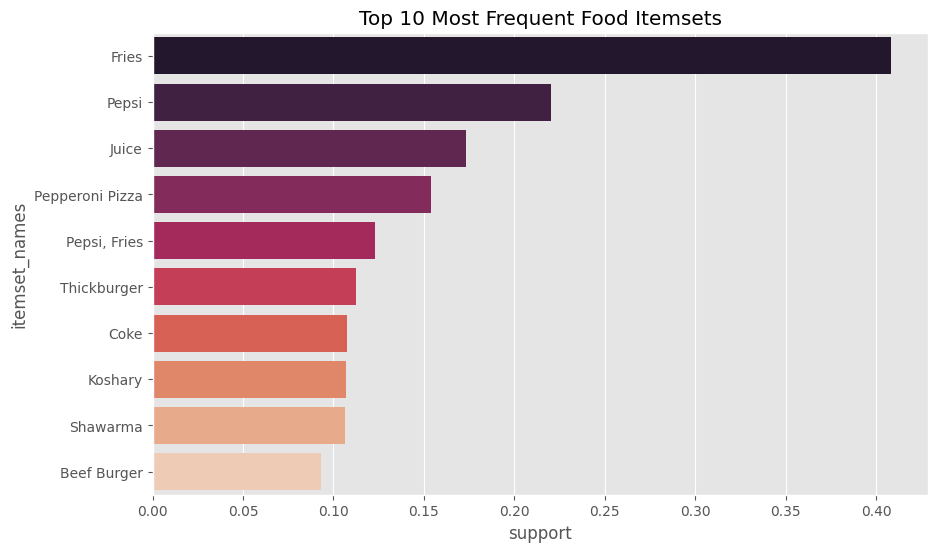

In [38]:
# Plot 1: Top 10 Frequent Itemsets
plt.figure(figsize=(10, 6))
top_10 = frequent_results[0.05].sort_values(by='support', ascending=False).head(10)
top_10['itemset_names'] = top_10['itemsets'].apply(lambda x: ', '.join(list(x)))

sns.barplot(x='support', y='itemset_names', data=top_10, palette='rocket')
plt.title('Top 10 Most Frequent Food Itemsets')
plt.show()